In [52]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

sns.set_theme(style="whitegrid")

In [53]:
df_movies = pd.read_csv("Dataset/tmdb_5000_movies.csv")
df_credits = pd.read_csv("Dataset/tmdb_5000_credits.csv")
df = pd.merge(df_movies, df_credits, left_on="id", right_on="movie_id")

df.shape
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [55]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count,movie_id
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989,57165.484281
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891,88694.614033
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,5.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000,9014.500000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000,14629.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000,58610.500000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000,459488.000000


Valori Mancanti:
homepage        3091
tagline          844
overview           3
runtime            2
release_date       1
dtype: int64

Valori Presenti: budget                  4803
genres                  4803
id                      4803
keywords                4803
original_title          4803
original_language       4803
production_companies    4803
popularity              4803
cast                    4803
title_y                 4803
production_countries    4803
revenue                 4803
status                  4803
spoken_languages        4803
vote_average            4803
title_x                 4803
crew                    4803
movie_id                4803
vote_count              4803
release_date            4802
runtime                 4801
overview                4800
tagline                 3959
homepage                1712
dtype: int64

Duplicati: 0


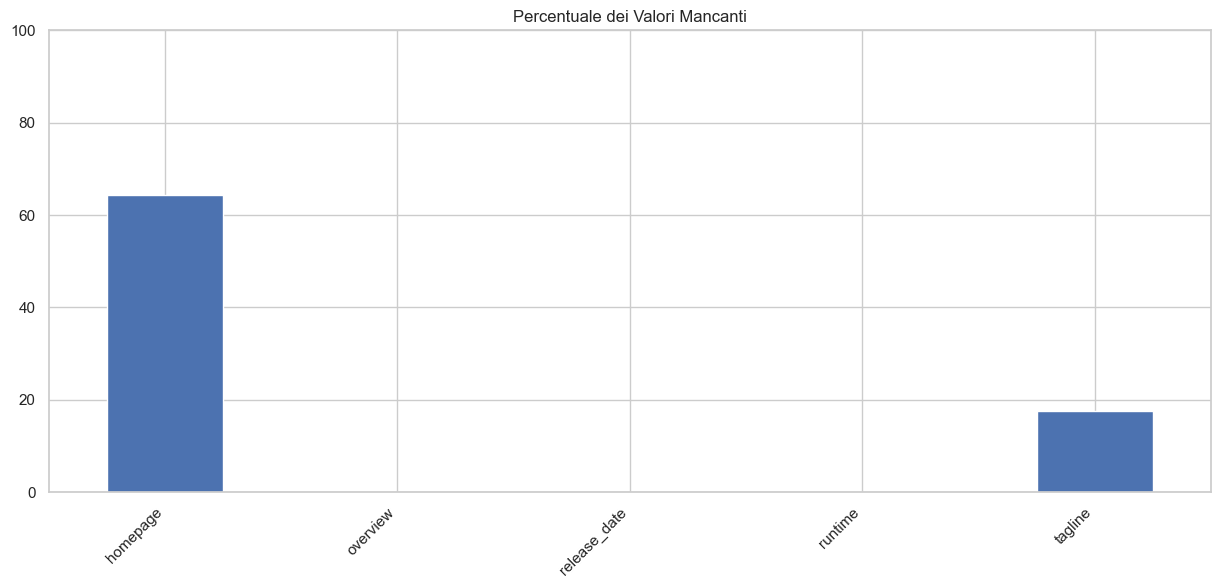

In [ ]:
# Analisi dei valori mancanti e duplicati
null_val = df.isnull().sum().sort_values(ascending=False)
print("Valori Mancanti:")
print(null_val[null_val > 0])

present_val = df.notnull().sum().sort_values(ascending=False)
print("\nValori Presenti:", present_val[present_val > 0])
df_plot = pd.DataFrame({
    'Presenti': present_val,
    'Mancanti': null_val
})

print("\nDuplicati:", df.duplicated().sum())

null_perc = (df.isnull().sum() / len(df)) * 100
null_perc[null_perc > 0].plot(kind="bar", figsize=(15, 6), title="Percentuale dei Valori Mancanti")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.show()

In [57]:
# Passaggio da json a lista di stringhe per le colonne specificate
def clean_json(json_text):
    if pd.isna(json_text) or not isinstance(json_text, str):
        return []
    
    try:

        converted_list = ast.literal_eval(json_text)
        return [item["name"] for item in converted_list if "name" in item]
    except (ValueError, SyntaxError):
        return []
    
colonne_json = [
    "genres",
    "keywords",
    "production_companies",
    "production_countries",
    "spoken_languages",
    "cast",
    "crew"
]
for col in colonne_json:
        df[col] = df[col].apply(clean_json)
df.head() 

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",http://www.avatarmovie.com/,19995,"[culture clash, future, space war, space colon...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...",...,"[English, Español]",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weave...","[Stephen E. Rivkin, Rick Carter, Christopher B..."
1,300000000,"[Adventure, Fantasy, Action]",http://disney.go.com/disneypictures/pirates/,285,"[ocean, drug abuse, exotic island, east india ...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",...,[English],Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley, ...","[Dariusz Wolski, Gore Verbinski, Jerry Bruckhe..."
2,245000000,"[Action, Adventure, Crime]",http://www.sonypictures.com/movies/spectre/,206647,"[spy, based on novel, secret agent, sequel, mi...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[Columbia Pictures, Danjaq, B24]",...,"[Français, English, Español, Italiano, Deutsch]",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R...","[Thomas Newman, Sam Mendes, Anna Pinnock, John..."
3,250000000,"[Action, Crime, Drama, Thriller]",http://www.thedarkknightrises.com/,49026,"[dc comics, crime fighter, terrorist, secret i...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",...,[English],Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman, A...","[Hans Zimmer, Charles Roven, Christopher Nolan..."
4,260000000,"[Action, Adventure, Science Fiction]",http://movies.disney.com/john-carter,49529,"[based on novel, mars, medallion, space travel...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,[Walt Disney Pictures],...,[English],Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton,...","[Andrew Stanton, Andrew Stanton, John Lasseter..."


In [58]:
# Pulizia e trasformazione dei dati
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year.astype("Int64")
df = df.drop(["title_y", "tagline", "homepage", "movie_id", "status"], axis = 1)
df = df.dropna(subset=["runtime"])
df = df.rename(columns={"title_x": "title"})
df = df[(df["budget"] > 0) & (df["revenue"] > 0) & (df["vote_average"] > 0)]
df["roi"] = (df["revenue"] - df["budget"]) / df["budget"] * 100

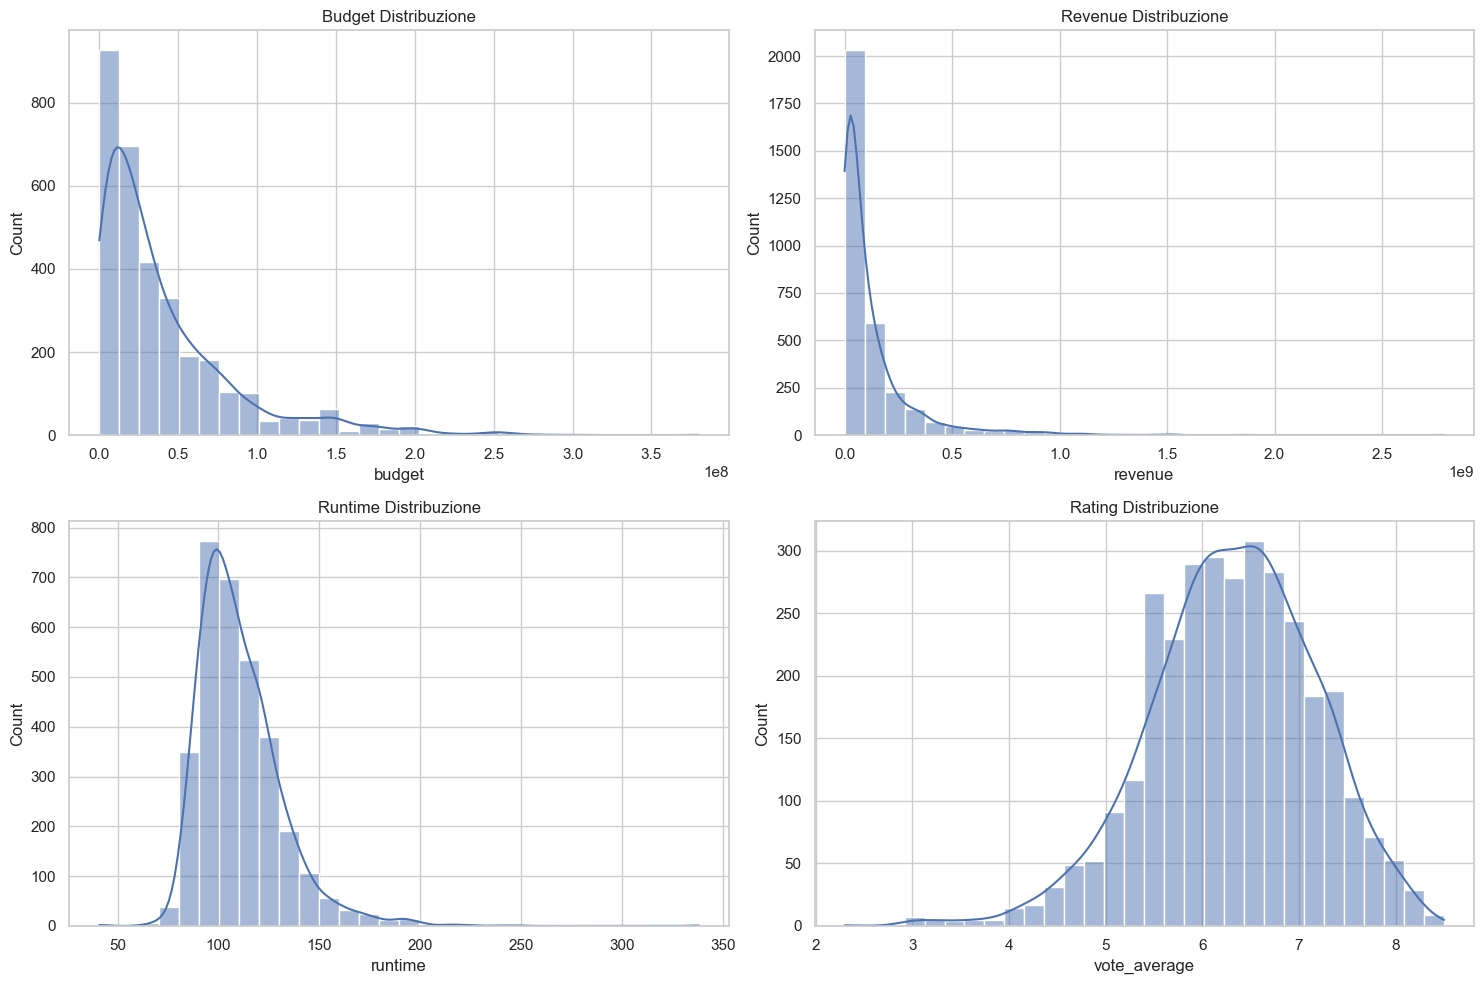

In [59]:
# Creiamo l'istogramma con la curva KDE
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(df["budget"], bins=30, kde=True, ax=axes[0, 0]).set_title("Budget Distribuzione")
sns.histplot(df["revenue"], bins=30, kde=True, ax=axes[0, 1]).set_title("Revenue Distribuzione")
sns.histplot(df["runtime"].dropna(), bins=30, kde=True, ax=axes[1, 0]).set_title("Runtime Distribuzione")
sns.histplot(df["vote_average"], bins=30, kde=True, ax=axes[1, 1]).set_title("Rating Distribuzione")
plt.tight_layout()
plt.show()

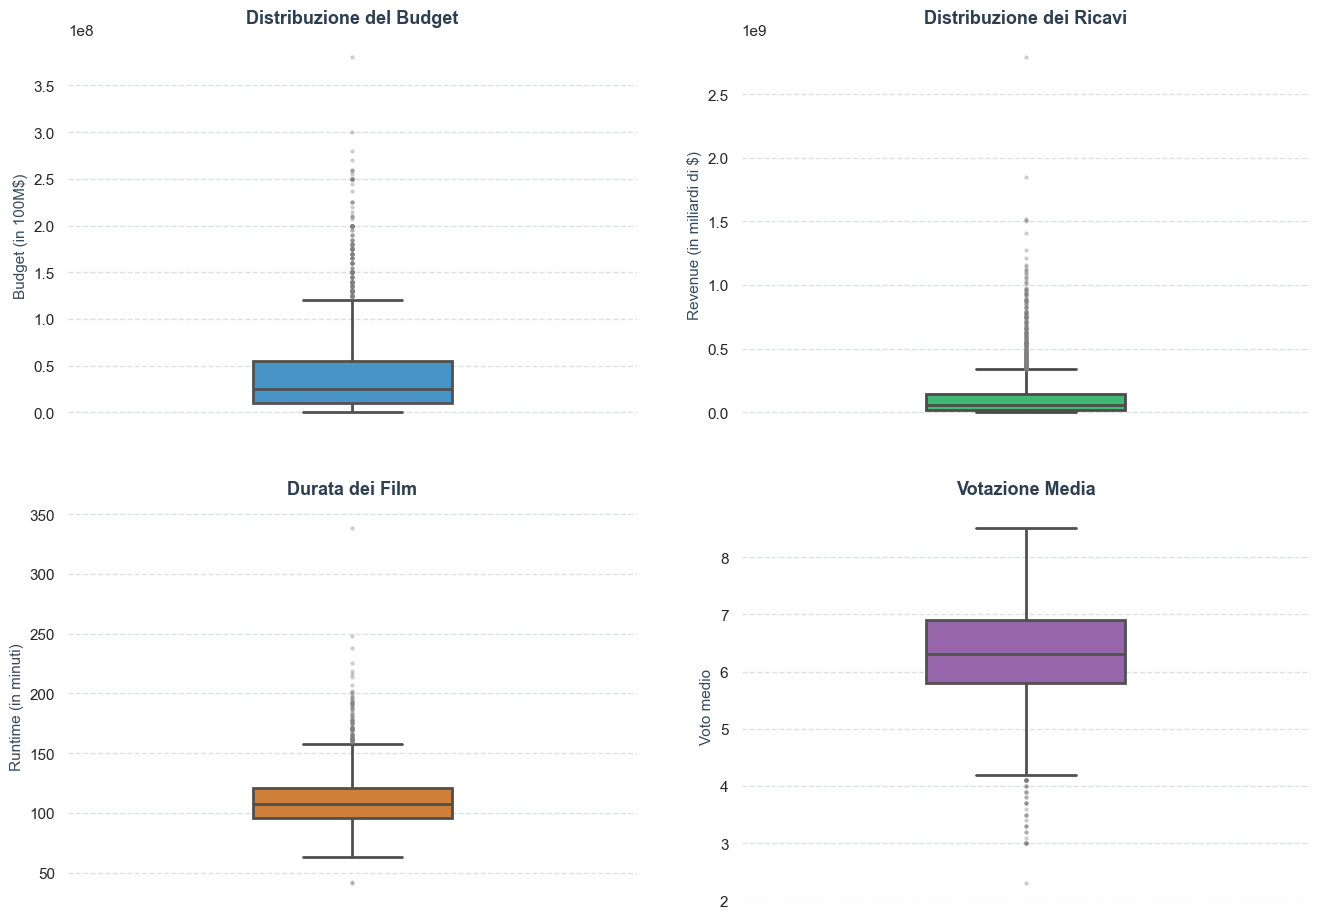

In [60]:
sns.set_theme(style="white")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# Configurazione per ogni grafico)
config = [
    {"col": "budget", "title": "Distribuzione del Budget", "ylabel": "Budget (in 100M$)", "color": "#3498db"},
    {"col": "revenue", "title": "Distribuzione dei Ricavi", "ylabel": "Revenue (in miliardi di $)", "color": "#2ecc71"},
    {"col": "runtime", "title": "Durata dei Film", "ylabel": "Runtime (in minuti)", "color": "#e67e22"},
    {"col": "vote_average", "title": "Votazione Media", "ylabel": "Voto medio", "color": "#9b59b6"}
]

for i, cfg in enumerate(config):
    sns.boxplot(
        data=df, 
        y=cfg["col"], 
        ax=axes[i], 
        color=cfg["color"],
        width=0.35,         
        linewidth=2,        
        fliersize=3,        
        flierprops={        
            "markerfacecolor": "gray", 
            "alpha": 0.4, 
            "markeredgecolor": "none"
        } 
    )
    
    axes[i].set_title(cfg["title"], fontsize=13, fontweight='bold', pad=12, color='#2c3e50')
    axes[i].set_ylabel(cfg["ylabel"], fontsize=11, color='#34495e')
    axes[i].set_xlabel("") 
    
    axes[i].yaxis.grid(True, linestyle='--', alpha=0.5, color='#bdc3c7')
    axes[i].xaxis.grid(False)
    
    sns.despine(ax=axes[i], left=True, bottom=True)

plt.tight_layout(pad=3.0)
plt.show()

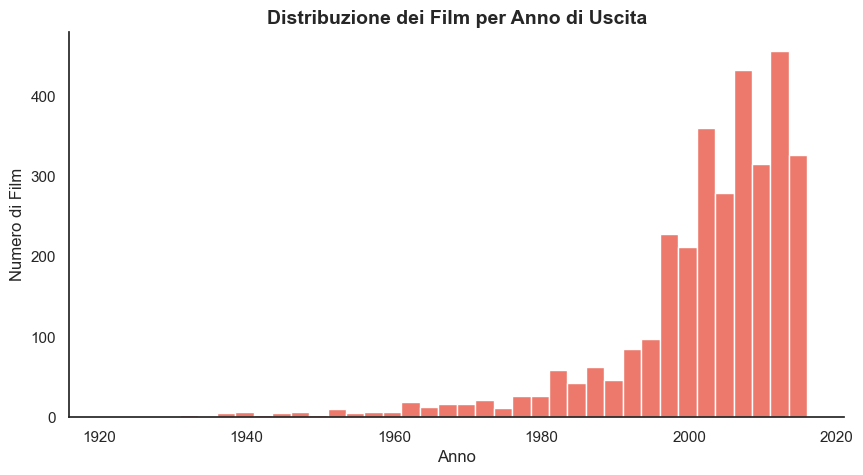

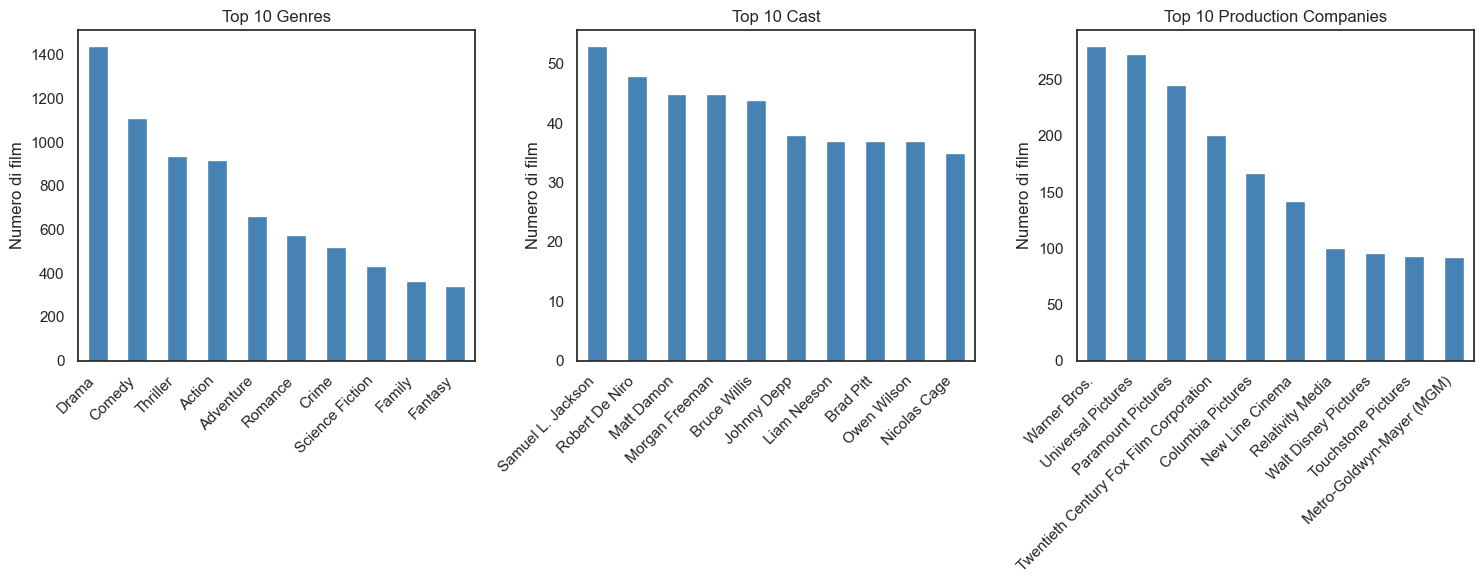

Generi totali: 19
Top 10 generi:
Drama              1439
Comedy             1110
Thriller            935
Action              918
Adventure           661
Romance             574
Crime               520
Science Fiction     431
Family              365
Fantasy             342
dtype: int64


In [61]:
anno_minimo = df["year"].min()
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="year", bins=40, color='#e74c3c', kde=False)

plt.xlim(left=anno_minimo)
plt.title("Distribuzione dei Film per Anno di Uscita", fontsize=14, fontweight='bold')
plt.xlabel("Anno")
plt.ylabel("Numero di Film")
sns.despine()
plt.show()


all_genres = [g for sublist in df["genres"] for g in sublist]
genre_counts = pd.Series(Counter(all_genres)).sort_values(ascending=False).head(10)

all_cast = [g for sublist in df["cast"] for g in sublist]
cast_counts = pd.Series(Counter(all_cast)).sort_values(ascending=False).head(10)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))
axes = axes.flatten()

all_prod_comp = [g for sublist in df["production_companies"] for g in sublist]
prod_comp_counts = pd.Series(Counter(all_prod_comp)).sort_values(ascending=False).head(10)

genre_counts.plot(kind="bar", color="steelblue", ax=axes[0])
axes[0].set_title("Top 10 Genres")
axes[0].set_ylabel("Numero di film")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

cast_counts.plot(kind="bar", color="steelblue", ax=axes[1])
axes[1].set_title("Top 10 Cast")
axes[1].set_ylabel("Numero di film")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

prod_comp_counts.plot(kind="bar", color="steelblue", ax=axes[2])
axes[2].set_title("Top 10 Production Companies")
axes[2].set_ylabel("Numero di film")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

genres = {g for sublist in df["genres"] for g in sublist}
print(f"Generi totali: {len(genres)}")
print(f"Top 10 generi:\n{genre_counts}")

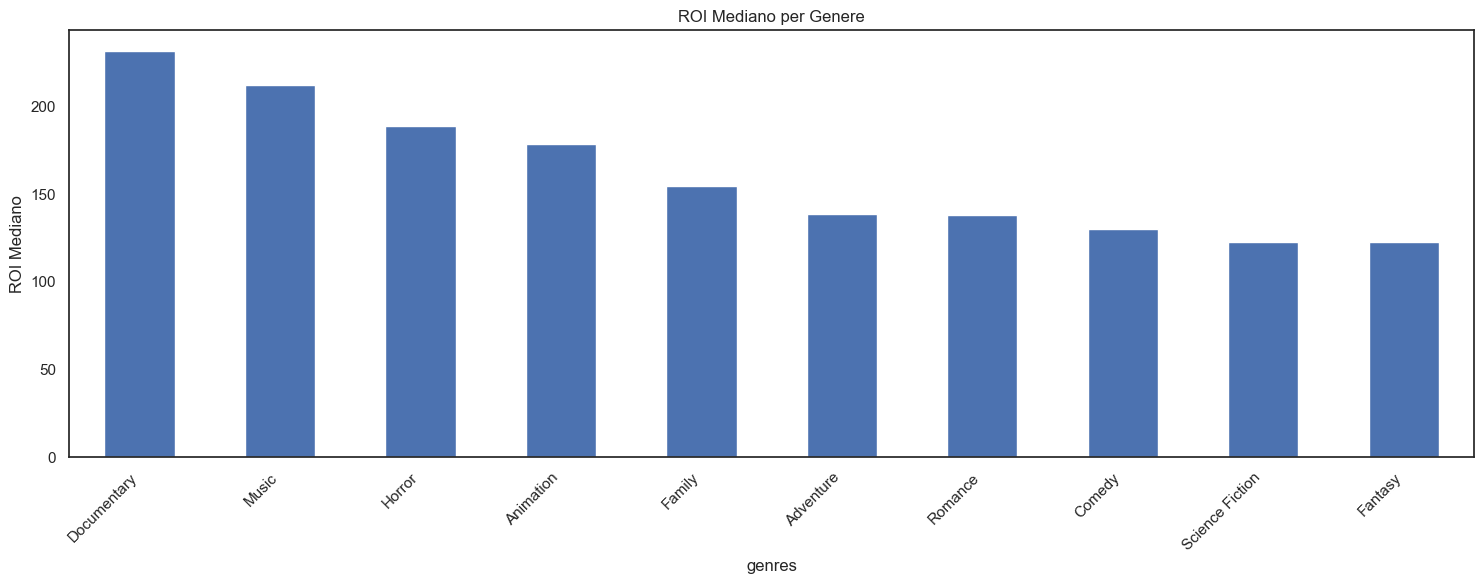

In [62]:
df_genres = df.explode("genres")
genre_roi = df_genres.groupby("genres")["roi"].median().sort_values(ascending=False).head(10)
genre_roi.plot(kind="bar", figsize=(15, 6), title="ROI Mediano per Genere")
plt.ylabel("ROI Mediano")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

                          title     revenue  vote_average
0                        Avatar  2787965087           7.2
25                      Titanic  1845034188           7.5
16                 The Avengers  1519557910           7.4
28               Jurassic World  1513528810           6.5
44                    Furious 7  1506249360           7.3
7       Avengers: Age of Ultron  1405403694           7.3
124                      Frozen  1274219009           7.3
31                   Iron Man 3  1215439994           6.8
546                     Minions  1156730962           6.4
26   Captain America: Civil War  1153304495           7.1


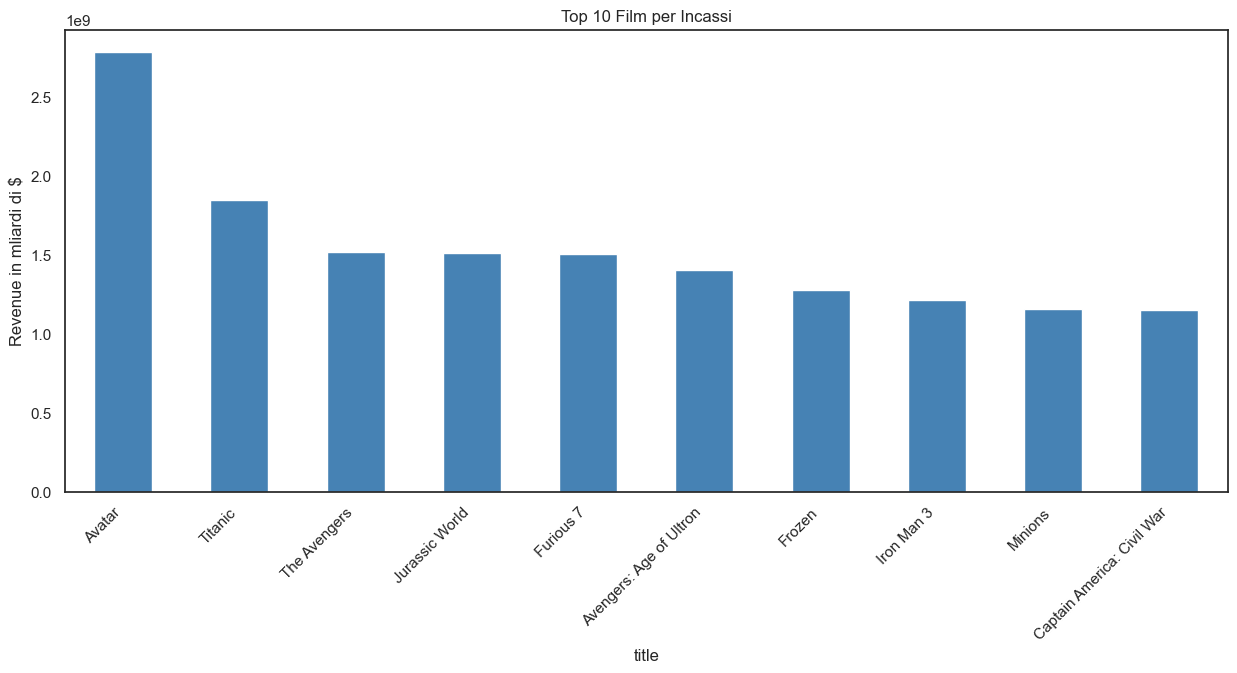

In [63]:
top_10_revenue = df.nlargest(10, "revenue")[["title", "revenue", "vote_average"]]
print(top_10_revenue)

top_10_revenue.plot(
    kind="bar",
    x="title",
    y="revenue",
    figsize=(15, 6),
    color="steelblue",
    title="Top 10 Film per Incassi",
    legend=False
)

plt.ylabel("Revenue in mliardi di $")
plt.xticks(rotation=45, ha="right") 
plt.show()

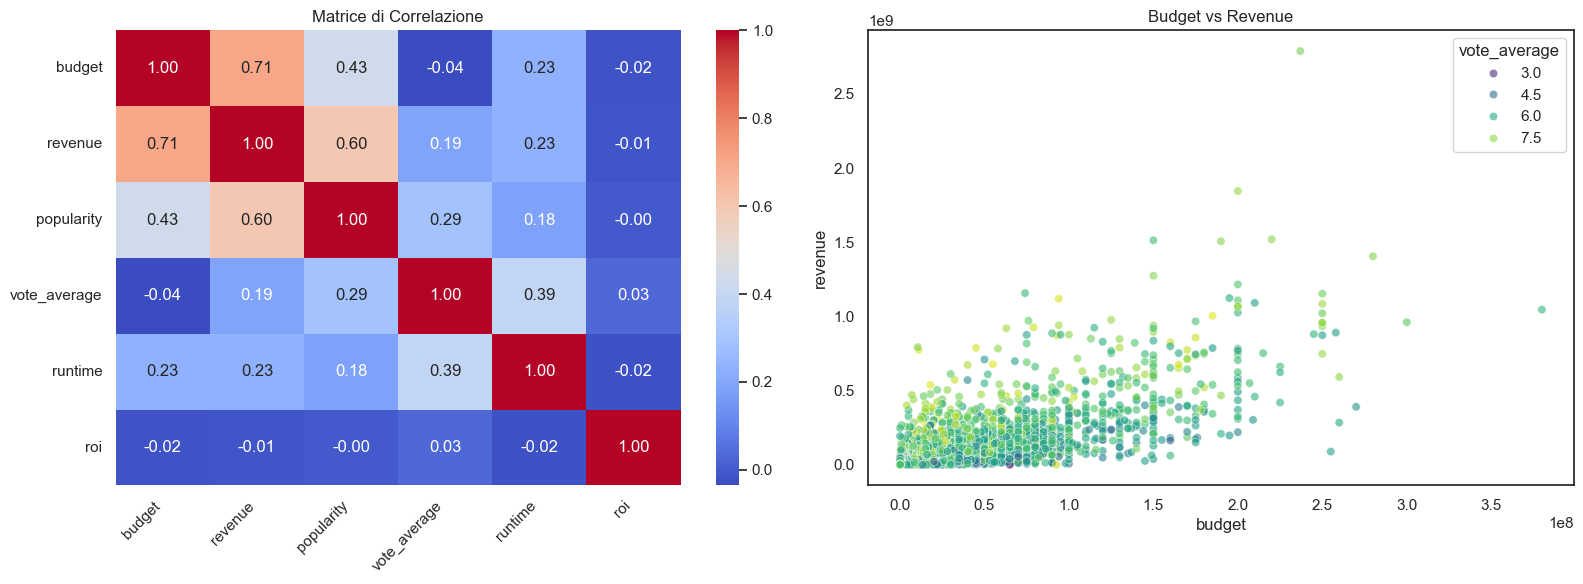

In [64]:
# Correlazioni 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_matrix = df[["budget", "revenue", "popularity", "vote_average", "runtime", "roi"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0])
axes[0].set_title("Matrice di Correlazione")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

sns.scatterplot(data=df, x="budget", y="revenue", hue="vote_average", palette="viridis", alpha=0.6, ax=axes[1])
axes[1].set_title("Budget vs Revenue")

plt.tight_layout()
plt.show()

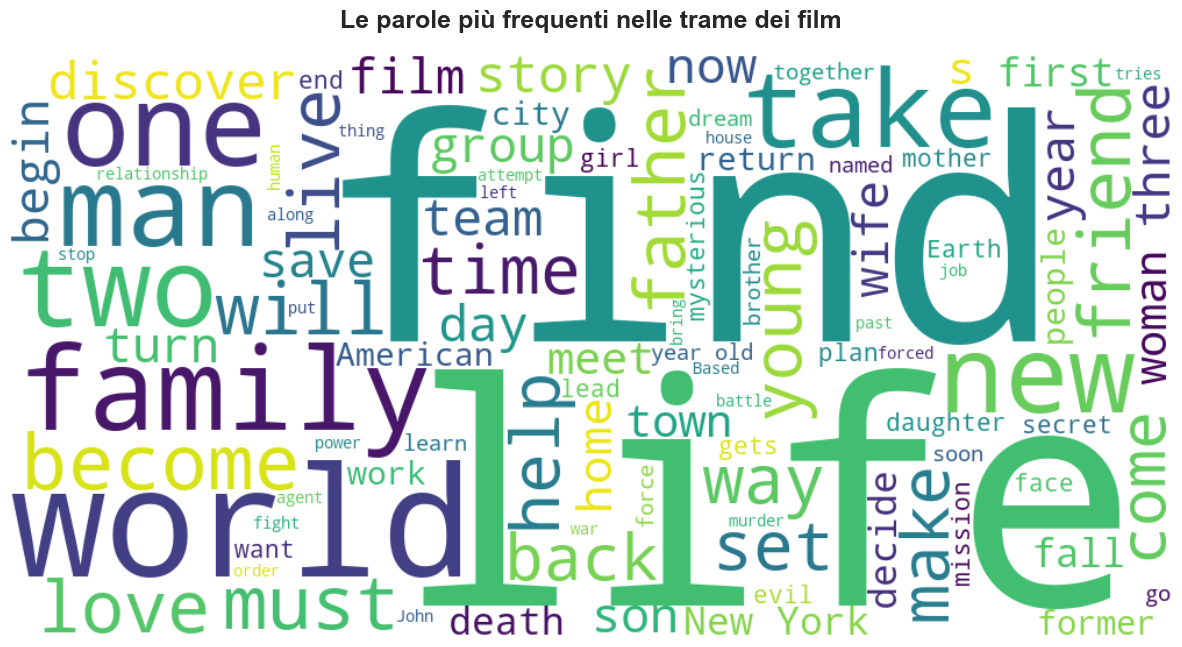

In [65]:
testo_trame = " ".join(df["overview"].dropna().values)

# Rimuoviamo le "stopwords" inglesi (parole inutili come "the", "and", "in")
stopwords = set(STOPWORDS)

wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white', 
    stopwords=stopwords,
    colormap='viridis',
    max_words=100
).generate(testo_trame)

# Mostriamo il risultato
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') 
plt.title('Le parole più frequenti nelle trame dei film', fontsize=18, fontweight='bold', pad=20)
plt.show()

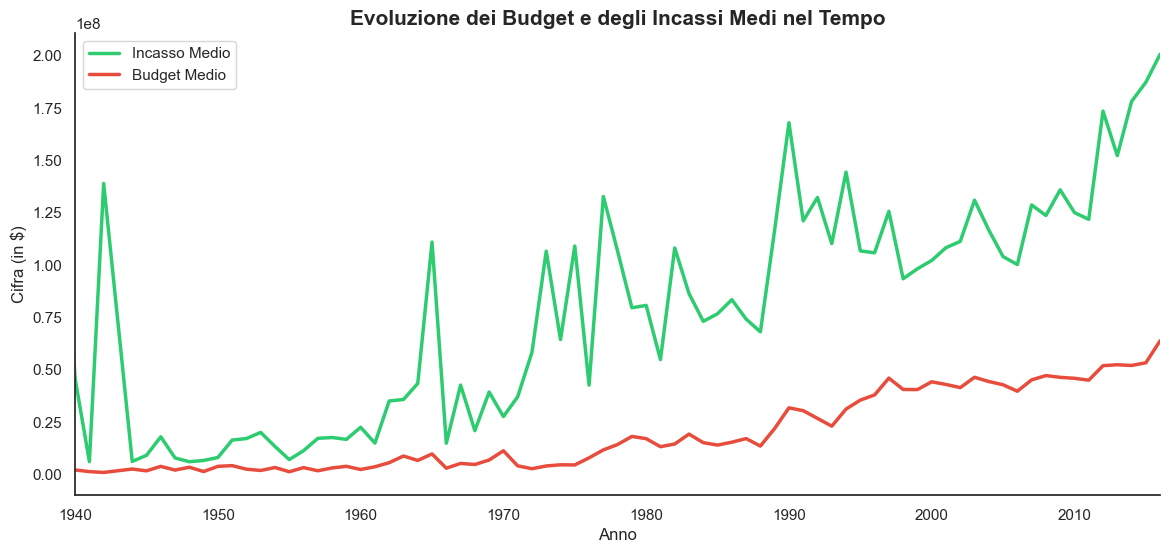

In [66]:
df_finanza = df[(df["budget"] > 0) & (df["revenue"] > 0)]
trend_finanziario = df_finanza.groupby("year")[[ "budget", "revenue"]].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=trend_finanziario, x="year", y="revenue", label="Incasso Medio", color="#2ecc71", linewidth=2.5)
sns.lineplot(data=trend_finanziario, x="year", y="budget", label="Budget Medio", color="#e74c3c", linewidth=2.5)

plt.title("Evoluzione dei Budget e degli Incassi Medi nel Tempo", fontsize=15, fontweight="bold")
plt.xlabel("Anno")
plt.ylabel("Cifra (in $)")
plt.xlim(1940, df["year"].max())

sns.despine()
plt.show()